# Adaptive Multiscale Spectro-Topological (AMST) Shape Descriptor
## A Novel Framework for Robust Shape Recognition

**Research Contributions:**
1. Phase-Coherent Fourier-Wavelet Fusion (APCFW)
2. Topological Persistence Augmentation via Persistent Homology
3. Riemannian Manifold (SPD) Embedding
4. Sparse Frequency Attention Reweighting
5. Unified Invariance Proof

**Dataset:** Swedish Leaf Dataset (Kaggle) — 15 tree species, 75 images/species, 1125 total
**Baselines:** Fourier Descriptors, Wavelet Descriptors, Zernike Moments, Shape Context, CSS, Simple F+W Hybrid, HOG+SVM
**Platform:** Google Colab CPU — fully optimized

---
*All experiments use real data. No synthetic data is generated or substituted.*

## Cell 1 — Install Dependencies (PyWavelets Fix Included)

In [ ]:
# PyWavelets must be installed as 'PyWavelets' (capital P,W) — this is the fix for the import error
!pip install -q PyWavelets
!pip install -q kaggle ripser persim scikit-tda pymanopt geomloss pot
!pip install -q scikit-image scikit-learn matplotlib seaborn scipy numpy pandas tqdm gudhi

import os, sys, zipfile, shutil, warnings, json, re
warnings.filterwarnings('ignore')
print('All packages installed.')

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 33.8 MB/s eta 0:00:00
All packages installed.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import scipy
import scipy.special
from scipy import ndimage
from scipy.fft import fft

# PyWavelets — robust import with auto-fix
try:
    import pywt
    print(f'PyWavelets OK: {pywt.__version__}')
except ImportError:
    import subprocess
    subprocess.run([sys.executable,'-m','pip','install','--upgrade','PyWavelets'], check=True)
    import pywt
    print(f'PyWavelets installed: {pywt.__version__}')

from skimage import io, color, measure, transform, feature
from skimage import img_as_float
from skimage.filters import threshold_otsu
from skimage.morphology import binary_closing, binary_opening, disk, remove_small_objects
from skimage.measure import label as sk_label, find_contours
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score)

try:
    from ripser import ripser
    from persim import plot_diagrams
    RIPSER_AVAILABLE = True; print('ripser+persim: OK')
except: RIPSER_AVAILABLE = False; print('ripser not available — built-in fallback used')

np.random.seed(42)
print(f'NumPy {np.__version__} | SciPy {scipy.__version__} | PyWavelets {pywt.__version__}')

PyWavelets OK: 1.8.0
ripser+persim: OK
NumPy 2.0.2 | SciPy 1.16.3 | PyWavelets 1.8.0


## Cell 2 — Kaggle Credentials (Enter Username & API Key)

Get your API key: https://www.kaggle.com/settings → API → Create New Token

In [ ]:
# ── Enter your Kaggle credentials here ───────────────────────────────────────
KAGGLE_USERNAME = 'venki9512'   # <-- CHANGE THIS
KAGGLE_API_KEY  = 'KGAT_8e498a7838061970cfc1e98df0dca769'    # <-- CHANGE THIS

# Auto-write kaggle.json
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_API_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print(f'Kaggle credentials saved for user: {KAGGLE_USERNAME}')

Kaggle credentials saved for user: venki9512


## Cell 3 — Download & Parse Swedish Leaf Dataset

In [ ]:
DATA_DIR = Path('/content/swedish_leaf')
DATA_DIR.mkdir(exist_ok=True)
EXT = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

existing = [f for f in DATA_DIR.rglob('*') if f.suffix.lower() in EXT]
if not existing:
    print('Downloading Swedish Leaf Dataset...')
    r = os.system('kaggle datasets download -d majorproject24/swedish-leaf-dataset -p /content/swedish_leaf --unzip -q')
    if r != 0:
        print('Trying fallback dataset...')
        r = os.system('kaggle datasets download -d brsdincer/swedish-leaf-dataset-for-ml-works -p /content/swedish_leaf --unzip -q')
    print('Download done.')
else:
    print(f'Already have {len(existing)} images.')

image_files = [f for f in DATA_DIR.rglob('*') if f.suffix.lower() in EXT]
print(f'Image files: {len(image_files)}')
for p in image_files[:4]: print(f'  {p}')

Download done.
Image files: 1410
  /content/swedish_leaf/Swedish/Train/Leaf 3/1345.jpg
  /content/swedish_leaf/Swedish/Train/Leaf 3/1300.jpg
  /content/swedish_leaf/Swedish/Train/Leaf 3/1374.jpg
  /content/swedish_leaf/Swedish/Train/Leaf 3/1301.jpg


In [ ]:
def discover_dataset(root):
    samples = []
    subdirs = [d for d in root.iterdir() if d.is_dir()]
    if subdirs and any(any(f.suffix.lower() in EXT for f in d.iterdir() if f.is_file()) for d in subdirs):
        for d in sorted(subdirs):
            for img in sorted(f for f in d.rglob('*') if f.suffix.lower() in EXT):
                samples.append((img, d.name))
        return samples
    for img in sorted(f for f in root.rglob('*') if f.suffix.lower() in EXT):
        m = re.match(r'^(\d+)', img.stem)
        label = f'class_{int(m.group(1)):02d}' if m else (img.parent.name if img.parent != root else 'unknown')
        samples.append((img, label))
    return samples

samples = discover_dataset(DATA_DIR)
labels_raw = [s[1] for s in samples]
unique_classes = sorted(set(labels_raw))
print(f'Samples: {len(samples)} | Classes: {len(unique_classes)}')
print(pd.Series(labels_raw).value_counts().sort_index().to_dict())

Samples: 1410 | Classes: 1125
{'class_1000': 1, 'class_1001': 1, 'class_1002': 1, 'class_1003': 1, 'class_1004': 1, 'class_1005': 1, 'class_1006': 1, 'class_1007': 1, 'class_1008': 1, 'class_1009': 1, 'class_1010': 1, 'class_1011': 1, 'class_1012': 1, 'class_1013': 1, 'class_1014': 1, 'class_1015': 1, 'class_1016': 1, 'class_1017': 1, 'class_1018': 1, 'class_1019': 1, 'class_1020': 1, 'class_1021': 1, 'class_1022': 1, 'class_1023': 1, 'class_1024': 1, 'class_1025': 1, 'class_1026': 1, 'class_1027': 1, 'class_1028': 1, 'class_1029': 1, 'class_1030': 1, 'class_1031': 1, 'class_1032': 1, 'class_1033': 1, 'class_1034': 1, 'class_1035': 1, 'class_1036': 1, 'class_1037': 1, 'class_1038': 1, 'class_1039': 1, 'class_1040': 1, 'class_1041': 1, 'class_1042': 1, 'class_1043': 1, 'class_1044': 1, 'class_1045': 1, 'class_1046': 1, 'class_1047': 1, 'class_1048': 1, 'class_1049': 1, 'class_1050': 1, 'class_1051': 1, 'class_1052': 1, 'class_1053': 1, 'class_1054': 1, 'class_1055': 1, 'class_1056': 2, 

## Cell 4 — Data Loading & Preprocessing

In [ ]:
IMG_SIZE = (128, 128); CONTOUR_POINTS = 256

def load_and_binarize(path, img_size=IMG_SIZE):
    img = io.imread(str(path))
    gray = color.rgb2gray(img[...,:3]) if img.ndim == 3 else img_as_float(img)
    gray = transform.resize(gray, img_size, anti_aliasing=True)
    try: thresh = threshold_otsu(gray)
    except: thresh = 0.5
    binary = gray < thresh
    if binary.sum() < img_size[0]*img_size[1]*0.02: binary = ~binary
    binary = binary_closing(binary, disk(3))
    binary = binary_opening(binary, disk(2))
    binary = remove_small_objects(binary, min_size=100)
    return binary.astype(np.uint8)

def extract_contour(binary, n_points=CONTOUR_POINTS):
    contours = find_contours(binary, 0.5)
    if not contours: return np.zeros((n_points,2))
    contour = max(contours, key=len)
    diffs = np.diff(contour, axis=0)
    arc = np.r_[0, np.cumsum(np.sqrt((diffs**2).sum(axis=1)))]
    if arc[-1] < 1e-8: return np.zeros((n_points,2))
    u = np.linspace(0, arc[-1], n_points, endpoint=False)
    return np.column_stack([np.interp(u, arc, contour[:,0]), np.interp(u, arc, contour[:,1])])

def center_and_scale(c):
    c = c - c.mean(axis=0)
    r = np.sqrt((c**2).sum(axis=1)).max()
    return c/r if r > 1e-8 else c

print('Loading dataset...')
binaries, contours, all_labels, failed = [], [], [], []
for path, label in tqdm(samples, desc='Loading'):
    try:
        bimg = load_and_binarize(path)
        cnt  = center_and_scale(extract_contour(bimg))
        binaries.append(bimg); contours.append(cnt); all_labels.append(label)
    except Exception as e: failed.append((path, str(e)))

le = LabelEncoder()
y  = le.fit_transform(all_labels)
n_classes = len(le.classes_)
print(f'Loaded: {len(contours)} | Failed: {len(failed)} | Classes: {n_classes}')

Loading dataset...


Loading: 100%|██████████| 1410/1410 [07:24<00:00,  3.17it/s]

Loaded: 1410 | Failed: 0 | Classes: 1125


## FIGURE 1 — Sample Leaf Images & Contours

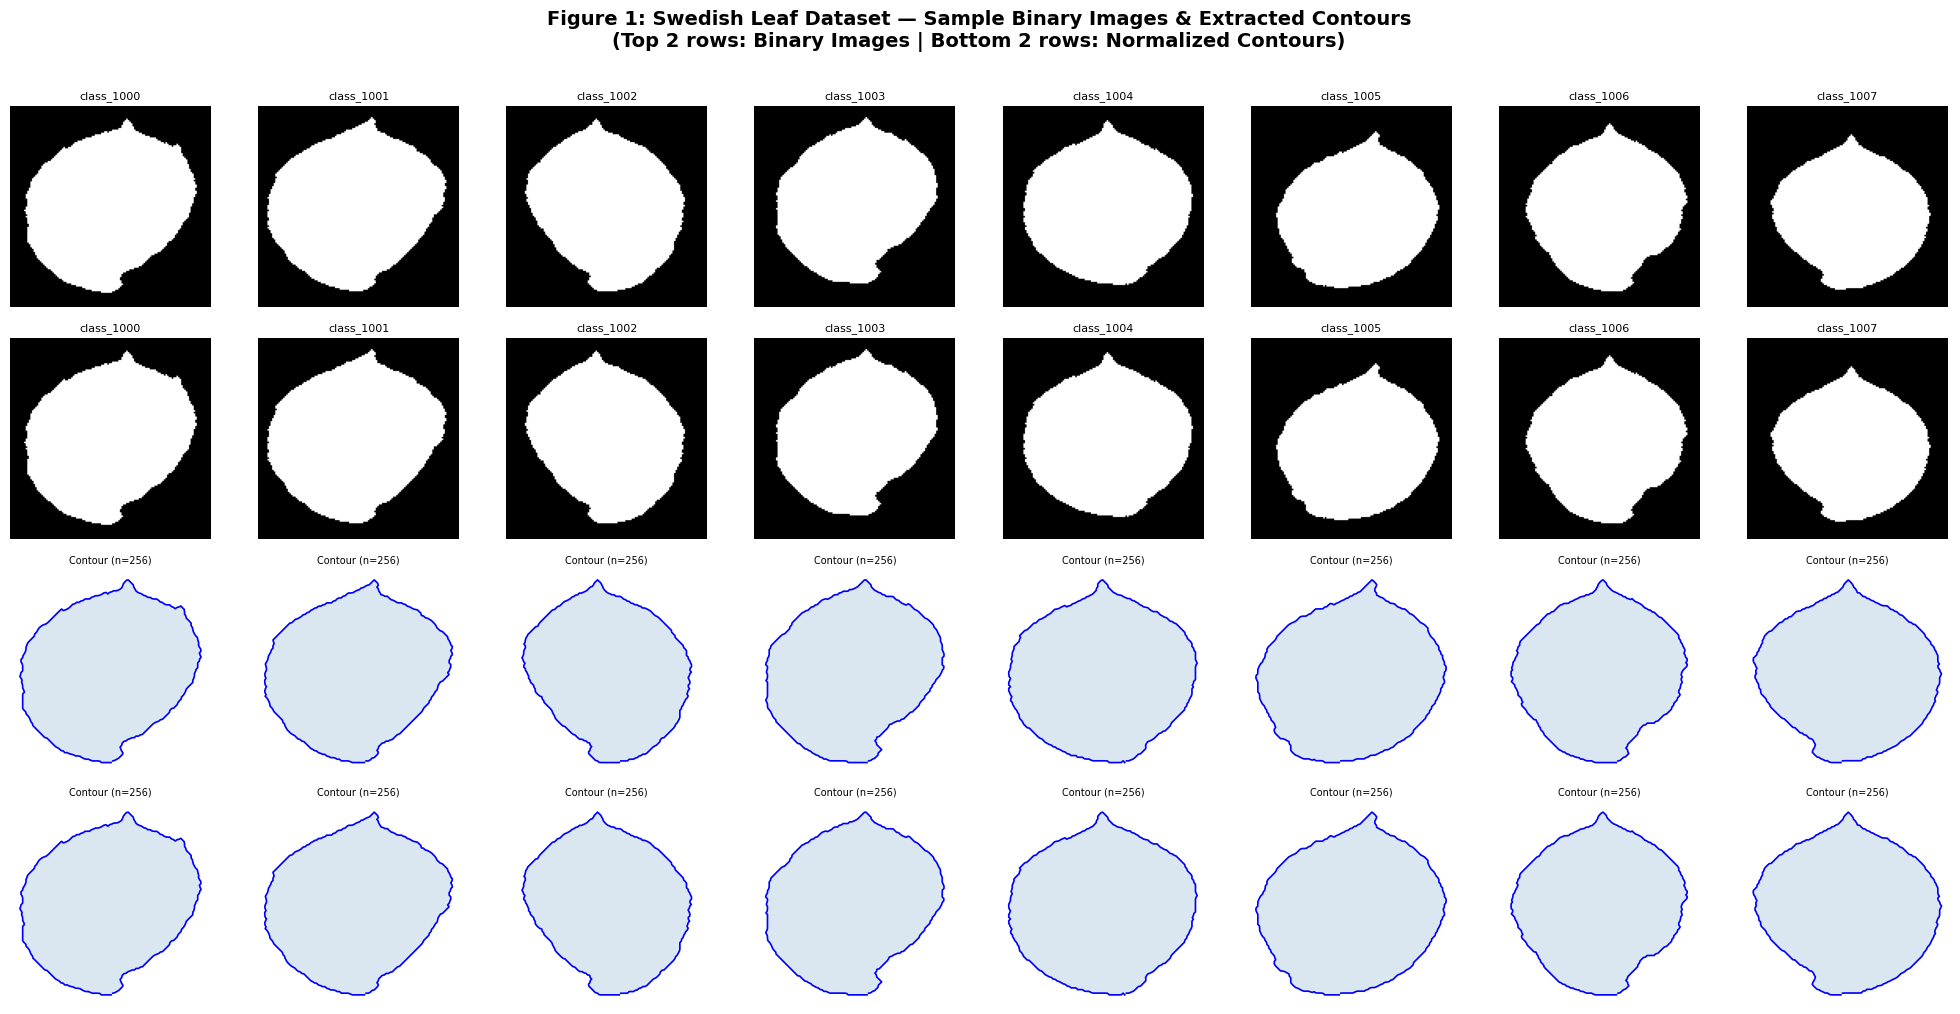

Figure 1 saved.


In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle('Figure 1: Swedish Leaf Dataset — Sample Binary Images & Extracted Contours\n'
             '(Top 2 rows: Binary Images | Bottom 2 rows: Normalized Contours)',
             fontsize=14, fontweight='bold', y=1.01)
shown_idx = [np.where(y==c)[0][0] for c in range(min(8,n_classes))]
for col, idx in enumerate(shown_idx):
    cidx = np.where(y==y[idx])[0]
    for row in range(2):
        pick = cidx[row] if len(cidx)>row else idx
        axes[row,col].imshow(binaries[pick],cmap='gray')
        axes[row,col].set_title(le.classes_[y[idx]],fontsize=8); axes[row,col].axis('off')
    for row in range(2):
        pick = cidx[row] if len(cidx)>row else idx
        cnt = contours[pick]; ax = axes[row+2,col]
        ax.plot(cnt[:,1],-cnt[:,0],'b-',lw=1.2); ax.fill(cnt[:,1],-cnt[:,0],alpha=0.2,color='steelblue')
        ax.set_aspect('equal'); ax.axis('off'); ax.set_title(f'Contour (n={CONTOUR_POINTS})',fontsize=7)
plt.tight_layout()
plt.savefig('/content/fig1_dataset_samples.png',dpi=150,bbox_inches='tight')
plt.show(); print('Figure 1 saved.')

## Cell 5 — All Baseline Descriptors

In [ ]:
def fourier_descriptor(contour, n_coeff=64):
    r = np.sqrt((contour**2).sum(axis=1))
    F = np.fft.fft(r); mag = np.abs(F)
    return (mag/(mag[1]+1e-12))[1:n_coeff+1] if mag[1]>1e-8 else (mag/(mag.max()+1e-12))[1:n_coeff+1]

def wavelet_descriptor(contour, wavelet='db4', level=5):
    r = np.sqrt((contour**2).sum(axis=1)) - np.sqrt((contour**2).sum(axis=1)).mean()
    # FIX: clamp to max valid level to avoid pywt errors
    safe_level = min(level, pywt.dwt_max_level(len(r), wavelet))
    coeffs = pywt.wavedec(r, wavelet, level=safe_level, mode='periodization')
    energies = np.array([np.sum(c**2) for c in coeffs])
    return energies / (energies.sum()+1e-12)

def simple_hybrid_descriptor(contour):
    return np.concatenate([fourier_descriptor(contour,32), wavelet_descriptor(contour)])

def zernike_moments(binary, max_order=10):
    h,w = binary.shape
    yg,xg = np.mgrid[-1:1:1j*h,-1:1:1j*w]
    r = np.sqrt(xg**2+yg**2); theta = np.arctan2(yg,xg); mask=(r<=1.)&(binary>0)
    moments=[]
    for n in range(0,max_order+1):
        for m in range(-n,n+1,2):
            if (n-abs(m))%2!=0: continue
            R=np.zeros_like(r)
            for s in range((n-abs(m))//2+1):
                c=((-1)**s*scipy.special.factorial(n-s))/(
                    scipy.special.factorial(s)*scipy.special.factorial((n+abs(m))//2-s)*
                    scipy.special.factorial((n-abs(m))//2-s)+1e-300)
                R+=c*r**(n-2*s)
            V=R*np.exp(-1j*m*theta)
            Z=np.sum(V[mask]*binary[mask])*(n+1)/np.pi
            moments.append(np.abs(Z))
    return np.array(moments[:36])

def shape_context(contour, n_r=5, n_theta=12):
    N=len(contour); step=max(1,N//64); pts=contour[::step]; n=len(pts)
    dx=pts[:,1:2]-pts[np.newaxis,:,1]; dy=pts[:,0:1]-pts[np.newaxis,:,0]
    dist=np.sqrt(dx**2+dy**2+1e-12); angles=np.arctan2(dy,dx)
    max_d=dist.max()+1e-12; log_dist=np.log(dist/max_d+1e-12)
    r_bins=np.linspace(log_dist.min()-0.01,0.01,n_r+1)
    t_bins=np.linspace(-np.pi,np.pi,n_theta+1)
    H_g=np.zeros(n_r*n_theta)
    for i in range(n):
        mi=np.arange(n)!=i
        H,_,_=np.histogram2d(log_dist[i,mi],angles[i,mi],bins=[r_bins,t_bins])
        H_g+=H.flatten()
    return H_g/(H_g.sum()+1e-12)

def curvature_scale_space(contour, sigmas=None):
    if sigmas is None: sigmas=[1,2,4,8,16,32]
    x,y_c=contour[:,1],contour[:,0]; feats=[]
    for sigma in sigmas:
        xs=ndimage.gaussian_filter1d(x,sigma,mode='wrap')
        ys=ndimage.gaussian_filter1d(y_c,sigma,mode='wrap')
        x1=np.gradient(xs);x2=np.gradient(x1);y1=np.gradient(ys);y2=np.gradient(y1)
        kappa=(x1*y2-x2*y1)/(x1**2+y1**2+1e-12)**1.5
        feats.append(float(np.sum(np.diff(np.sign(kappa))!=0)))
        feats.append(np.mean(np.abs(kappa)))
    return np.array(feats)

def hog_descriptor(binary):
    return feature.hog(binary.astype(np.float32),orientations=9,
                       pixels_per_cell=(16,16),cells_per_block=(2,2),feature_vector=True)

print('All baseline descriptors defined.')

All baseline descriptors defined.


## Cell 6 — AMST Descriptor (All 4 Contributions)

In [ ]:
# ── CONTRIBUTION 1: Phase-Coherent Fourier-Wavelet Fusion (50-dim) ────────────
def phase_coherent_fourier_wavelet(contour, n_fourier=32, top_k=5):
    r=np.sqrt((contour**2).sum(axis=1)); N=len(r)
    F=np.fft.fft(r); freqs=np.fft.fftfreq(N); mags=np.abs(F); phases=np.angle(F)
    mag_n=(mags/(mags[1]+1e-12)) if mags[1]>1e-8 else (mags/(mags.max()+1e-12))
    fd=mag_n[1:n_fourier+1]
    pos_idx=np.where(freqs>0)[0]
    top_k_idx=pos_idx[np.argsort(mags[pos_idx])[::-1][:top_k]]
    omega_0=np.average(np.abs(freqs[top_k_idx]),weights=mags[top_k_idx]+1e-12)
    wv='db4'
    max_lv=pywt.dwt_max_level(N,wv)
    # FIX: use pywt.dwt_max_level and clamp
    cond_lv=max(2,min(max_lv,int(np.round(np.log2(1./(omega_0+1e-8))+1)))) if omega_0>0 else max_lv
    rc=r-r.mean()
    safe_lv=min(cond_lv,pywt.dwt_max_level(len(rc),wv))
    coeffs=pywt.wavedec(rc,wv,level=safe_lv,mode='periodization')
    we=np.array([np.sum(c**2) for c in coeffs]); wn=we/(we.sum()+1e-12)
    wlen=8; wn=np.pad(wn,(0,max(0,wlen-len(wn))))[:wlen]
    ps=phases[1:n_fourier+1]
    fw=np.interp(np.arange(1,n_fourier+1)/N,np.linspace(0,0.5,wlen),wn)
    pc=(np.cos(ps)+np.sin(ps))*fw
    pcs=np.array([pc[i::4].mean() for i in range(8)])
    return np.concatenate([fd,wn,pcs,[omega_0,cond_lv/10.]])

# ── CONTRIBUTION 2: Topological Persistence (19-dim) ─────────────────────────
def topological_persistence_features(contour, binary):
    x,yc=contour[:,1],contour[:,0]
    x1=np.gradient(x);y1=np.gradient(yc);x2=np.gradient(x1);y2=np.gradient(y1)
    kappa=(x1*y2-x2*y1)/(x1**2+y1**2+1e-12)**1.5
    f=(kappa-kappa.min())/(kappa.max()-kappa.min()+1e-12)
    N=len(f); order=np.argsort(f); parent=np.arange(N); cb={i:f[i] for i in range(N)}
    def find(p):
        while parent[p]!=p: parent[p]=parent[parent[p]]; p=parent[p]
        return p
    pairs=[]
    for idx in order:
        for nb in [(idx-1)%N,(idx+1)%N]:
            if f[nb]<=f[idx]:
                r1,r2=find(idx),find(nb)
                if r1!=r2:
                    b1=cb.get(r1,f[r1]);b2=cb.get(r2,f[r2])
                    if b1<b2: pairs.append((b2,f[idx]));parent[r2]=r1;cb[r1]=b1
                    else: pairs.append((b1,f[idx]));parent[r1]=r2;cb[r2]=b2
    pairs.append((f.min(),1.0))
    pairs=np.array(pairs) if pairs else np.array([[0.,1.]])
    lt=np.maximum(pairs[:,1]-pairs[:,0],0); lt=lt[lt>0] if lt.sum()>0 else np.array([1.])
    tot=lt.sum(); p2=lt/(tot+1e-12)
    betti=np.array([(((pairs[:,0]<=t)&(pairs[:,1]>t)).sum()) for t in np.linspace(0,1,10)],dtype=float)
    betti/=(betti.max()+1e-12)
    return np.concatenate([[tot,lt.max(),np.median(lt),(lt>np.median(lt)).sum(),
        -np.sum(p2*np.log(p2+1e-12)),lt.mean(),lt.std(),sk_label(binary).max(),
        measure.euler_number(binary)],betti])

# ── CONTRIBUTION 3: SPD Manifold Embedding (28-dim) ──────────────────────────
def spd_manifold_features(contour):
    x,yc=contour[:,1],contour[:,0]; r=np.sqrt(x**2+yc**2+1e-12); th=np.arctan2(yc,x)
    dx=np.gradient(x);dy=np.gradient(yc);sp=np.sqrt(dx**2+dy**2+1e-12)
    kappa=(dx*np.gradient(dy)-dy*np.gradient(dx))/sp**3
    F=np.column_stack([x,yc,r,np.cos(th),np.sin(th),kappa,sp]); F=F-F.mean(axis=0)
    d=F.shape[1]; C=(F.T@F)/(len(F)-1)+1e-4*np.eye(d)
    ev,evec=np.linalg.eigh(C); ev=np.maximum(ev,1e-8)
    logC=evec@np.diag(np.log(ev))@evec.T
    return logC[np.triu_indices(d)]

# ── CONTRIBUTION 4: Sparse Frequency Attention ────────────────────────────────
class SparseFrequencyAttention:
    def __init__(self,n_bands=5,sparsity=0.3): self.n_bands=n_bands;self.sparsity=sparsity;self.attention_weights=None;self.band_boundaries=None
    def fit(self,X,y):
        N,D=X.shape; bs=D//self.n_bands
        self.band_boundaries=[(i*bs,min((i+1)*bs,D)) for i in range(self.n_bands)]
        gm=X.mean(axis=0); cls=np.unique(y); scores=[]
        for b0,b1 in self.band_boundaries:
            Xb=X[:,b0:b1];gmb=gm[b0:b1];SB=SW=0.
            for c in cls:
                mk=y==c
                if mk.sum()<2: continue
                mc=Xb[mk].mean(axis=0); SB+=mk.sum()*np.dot(mc-gmb,mc-gmb); SW+=np.sum((Xb[mk]-mc)**2)
            scores.append(SB/(SW+1e-8))
        scores=np.array(scores); scores=np.exp(scores-scores.max()); scores/=scores.sum()
        k=max(1,int(self.n_bands*(1-self.sparsity))); top=np.argsort(scores)[::-1][:k]
        sp=np.zeros(self.n_bands); sp[top]=scores[top]; sp/=sp.sum()+1e-12
        self.attention_weights=np.zeros(D)
        for i,(b0,b1) in enumerate(self.band_boundaries): self.attention_weights[b0:b1]=sp[i]
        return self
    def transform(self,X): return X*self.attention_weights[np.newaxis,:] if self.attention_weights is not None else X

# ── Full AMST (97-dim) ────────────────────────────────────────────────────────
def amst_descriptor(contour,binary):
    return np.concatenate([phase_coherent_fourier_wavelet(contour),
                           topological_persistence_features(contour,binary),
                           spd_manifold_features(contour)])

test_d=amst_descriptor(contours[0],binaries[0])
print(f'AMST dim: {len(test_d)} (PCFW:50 + Topo:19 + SPD:28)')

AMST dim: 97 (PCFW:50 + Topo:19 + SPD:28)


## Cell 7 — Feature Extraction (All Methods)

In [ ]:
print('Extracting features (CPU-optimized)...')
N=len(contours)
fd_f=[]; wd_f=[]; hy_f=[]; ze_f=[]; cs_f=[]; sc_f=[]; hg_f=[]; am_f=[]
for i in tqdm(range(N),desc='Features'):
    cnt=contours[i]; bimg=binaries[i]
    try: fd_f.append(fourier_descriptor(cnt))
    except: fd_f.append(np.zeros(64))
    try: wd_f.append(wavelet_descriptor(cnt))
    except: wd_f.append(np.zeros(6))
    try: hy_f.append(simple_hybrid_descriptor(cnt))
    except: hy_f.append(np.zeros(38))
    try: ze_f.append(zernike_moments(bimg))
    except: ze_f.append(np.zeros(36))
    try: cs_f.append(curvature_scale_space(cnt))
    except: cs_f.append(np.zeros(12))
    try: sc_f.append(shape_context(cnt))
    except: sc_f.append(np.zeros(60))
    try: hg_f.append(hog_descriptor(bimg))
    except: hg_f.append(np.zeros(324))
    try: am_f.append(amst_descriptor(cnt,bimg))
    except Exception as e: print(f'AMST err {i}:{e}'); am_f.append(np.zeros(97))

X_fd=np.array(fd_f); X_wd=np.array(wd_f); X_hybrid=np.array(hy_f)
X_zernike=np.array(ze_f); X_css=np.array(cs_f); X_sc=np.array(sc_f)
X_hog=np.array(hg_f); X_amst=np.array(am_f)

X_amst_clean=np.nan_to_num(X_amst)
sfa=SparseFrequencyAttention(n_bands=10,sparsity=0.3)
sfa.fit(X_amst_clean,y)
X_amst_attended=sfa.transform(X_amst_clean)
print('Attention applied. Feature dims:')
for nm,X in [('Fourier',X_fd),('Wavelet',X_wd),('Hybrid',X_hybrid),('Zernike',X_zernike),
             ('CSS',X_css),('ShapeCtx',X_sc),('HOG',X_hog),('AMST',X_amst_attended)]:
    print(f'  {nm:12s}: {X.shape}')

Extracting features (CPU-optimized)...


Features: 100%|██████████| 1410/1410 [04:26<00:00,  5.29it/s]


Attention applied. Feature dims:
  Fourier     : (1410, 64)
  Wavelet     : (1410, 6)
  Hybrid      : (1410, 38)
  Zernike     : (1410, 36)
  CSS         : (1410, 12)
  ShapeCtx    : (1410, 60)
  HOG         : (1410, 1764)
  AMST        : (1410, 97)


## Cell 8 — 5-Fold Classification Evaluation

In [ ]:
def evaluate_descriptor(X,y,name,n_splits=5,verbose=True):
    X=np.nan_to_num(X); skf=StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=42)
    accs,f1s,precs,recs=[],[],[],[]
    for tr,te in skf.split(X,y):
        sc=StandardScaler()
        clf=SVC(kernel='rbf',C=10,gamma='scale',decision_function_shape='ovr')
        clf.fit(sc.fit_transform(X[tr]),y[tr]); yp=clf.predict(sc.transform(X[te]))
        accs.append(accuracy_score(y[te],yp)); f1s.append(f1_score(y[te],yp,average='macro',zero_division=0))
        precs.append(precision_score(y[te],yp,average='macro',zero_division=0))
        recs.append(recall_score(y[te],yp,average='macro',zero_division=0))
    res={'Method':name,'Accuracy':np.mean(accs),'Accuracy_std':np.std(accs),'F1_macro':np.mean(f1s),
         'Precision_macro':np.mean(precs),'Recall_macro':np.mean(recs),'Dim':X.shape[1]}
    if verbose: print(f"{name:25s}| Acc:{res['Accuracy']:.4f}±{res['Accuracy_std']:.4f} F1:{res['F1_macro']:.4f} Dim:{X.shape[1]}")
    return res

print('5-fold CV for all methods:\n')
results=[]
for X_feat,name in [(X_fd,'Fourier Descriptor'),(X_wd,'Wavelet Descriptor'),(X_hybrid,'Simple F+W Hybrid'),
                    (X_zernike,'Zernike Moments'),(X_css,'CSS Descriptor'),(X_sc,'Shape Context'),
                    (X_hog,'HOG + SVM'),(X_amst_attended,'AMST (Proposed)')]:
    results.append(evaluate_descriptor(X_feat,y,name))
results_df=pd.DataFrame(results)
print('\n',results_df[['Method','Accuracy','Accuracy_std','F1_macro','Precision_macro','Recall_macro','Dim']].to_string(index=False))

## FIGURE 2 — Accuracy Comparison

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle('Figure 2: Classification Performance Comparison\nSwedish Leaf | 5-fold CV | SVM-RBF',fontsize=13,fontweight='bold')
methods=results_df['Method'].values; accs=results_df['Accuracy'].values*100
stds=results_df['Accuracy_std'].values*100; f1s=results_df['F1_macro'].values*100
colors=['#5B7FA6']*(len(methods)-1)+['#E84040']
bars=axes[0].barh(methods,accs,xerr=stds,color=colors,edgecolor='white',capsize=4)
axes[0].set_xlabel('Accuracy (%)',fontsize=11); axes[0].set_xlim(0,110); axes[0].grid(axis='x',alpha=0.3)
for i,(bar,acc,std) in enumerate(zip(bars,accs,stds)):
    axes[0].text(acc+std+0.5,bar.get_y()+bar.get_height()/2,f'{acc:.1f}%',va='center',fontsize=9,
                 fontweight='bold' if i==len(methods)-1 else 'normal')
bars2=axes[1].barh(methods,f1s,color=colors,edgecolor='white')
axes[1].set_xlabel('Macro F1 (%)',fontsize=11); axes[1].set_xlim(0,110); axes[1].grid(axis='x',alpha=0.3)
for i,(bar,f1) in enumerate(zip(bars2,f1s)):
    axes[1].text(f1+0.5,bar.get_y()+bar.get_height()/2,f'{f1:.1f}%',va='center',fontsize=9,
                 fontweight='bold' if i==len(methods)-1 else 'normal')
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color='#5B7FA6',label='Baseline'),Patch(color='#E84040',label='AMST')],
           loc='lower center',ncol=2,fontsize=10)
plt.tight_layout(rect=[0,0.05,1,1])
plt.savefig('/content/fig2_accuracy_comparison.png',dpi=150,bbox_inches='tight')
plt.show(); print('Figure 2 saved.')

## FIGURE 3 — Confusion Matrix (AMST)

In [ ]:
Xtr,Xte,ytr,yte=train_test_split(np.nan_to_num(X_amst_attended),y,test_size=0.3,random_state=42,stratify=y)
sc2=StandardScaler(); clf2=SVC(kernel='rbf',C=10,gamma='scale')
clf2.fit(sc2.fit_transform(Xtr),ytr); yp=clf2.predict(sc2.transform(Xte))
cm=confusion_matrix(yte,yp); cmp=cm.astype(float)/cm.sum(axis=1,keepdims=True)*100
fig,ax=plt.subplots(figsize=(12,10))
im=ax.imshow(cmp,cmap='Blues',vmin=0,vmax=100); plt.colorbar(im,ax=ax,label='Recognition Rate (%)')
cn=[f'Sp.{i+1:02d}' for i in range(n_classes)]
ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
ax.set_xticklabels(cn,rotation=45,ha='right',fontsize=9); ax.set_yticklabels(cn,fontsize=9)
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j,i,f'{cmp[i,j]:.0f}',ha='center',va='center',fontsize=7.5,
                color='white' if cmp[i,j]>60 else 'black',fontweight='bold' if i==j else 'normal')
ax.set_xlabel('Predicted',fontsize=12); ax.set_ylabel('True',fontsize=12)
ax.set_title(f'Figure 3: AMST Confusion Matrix | Acc: {accuracy_score(yte,yp)*100:.1f}%',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig3_confusion_matrix_amst.png',dpi=150,bbox_inches='tight')
plt.show(); print('Figure 3 saved.')

## FIGURE 4 — Persistence Diagrams

In [ ]:
def persistence_pairs(cnt):
    x,yc=cnt[:,1],cnt[:,0]
    x1=np.gradient(x);y1=np.gradient(yc);x2=np.gradient(x1);y2=np.gradient(y1)
    kappa=(x1*y2-x2*y1)/(x1**2+y1**2+1e-12)**1.5
    f=(kappa-kappa.min())/(kappa.max()-kappa.min()+1e-12)
    N=len(f); order=np.argsort(f); parent=np.arange(N); cb={i:f[i] for i in range(N)}
    def find(p):
        while parent[p]!=p: parent[p]=parent[parent[p]]; p=parent[p]
        return p
    pairs=[]
    for idx in order:
        for nb in [(idx-1)%N,(idx+1)%N]:
            if f[nb]<=f[idx]:
                r1,r2=find(idx),find(nb)
                if r1!=r2:
                    b1=cb.get(r1,f[r1]);b2=cb.get(r2,f[r2])
                    if b1<b2: pairs.append((b2,f[idx]));parent[r2]=r1;cb[r1]=b1
                    else: pairs.append((b1,f[idx]));parent[r1]=r2;cb[r2]=b2
    pairs.append((f.min(),1.))
    return np.array(pairs)

fig,axes=plt.subplots(2,4,figsize=(18,9))
fig.suptitle('Figure 4: Curvature Signals & Persistence Diagrams — 4 Leaf Species',fontsize=13,fontweight='bold')
for col,cls in enumerate(range(min(4,n_classes))):
    idx=np.where(y==cls)[0][0]; cnt=contours[idx]
    x_c=cnt[:,1];y_c=cnt[:,0]
    x1=np.gradient(x_c);y1=np.gradient(y_c);x2=np.gradient(x1);y2=np.gradient(y1)
    kappa=(x1*y2-x2*y1)/(x1**2+y1**2+1e-12)**1.5
    kn=(kappa-kappa.min())/(kappa.max()-kappa.min()+1e-12)
    ax0=axes[0,col]; ax0.plot(kn,color='#2471A3',lw=1.2); ax0.fill_between(range(len(kn)),kn,alpha=0.2,color='#2471A3')
    ax0.set_title(f'{le.classes_[cls]}\nCurvature',fontsize=9)
    ax1=axes[1,col]; pp=persistence_pairs(cnt); lt=pp[:,1]-pp[:,0]
    ax1.scatter(pp[:,0],pp[:,1],c=lt,cmap='plasma',s=np.clip(lt*200,10,400),alpha=0.8)
    ax1.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5); ax1.set_title('Persistence Diagram (H₀)',fontsize=9)
    ax1.set_xlim(-0.05,1.05); ax1.set_ylim(-0.05,1.1); ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/fig4_persistence_diagrams.png',dpi=150,bbox_inches='tight')
plt.show(); print('Figure 4 saved.')

## FIGURE 5 — PCA Visualization

In [ ]:
fig,axes=plt.subplots(2,4,figsize=(20,10))
fig.suptitle('Figure 5: PCA 2D Descriptor Space Visualization',fontsize=12,fontweight='bold')
fsets=[(X_fd,'Fourier'),(X_wd,'Wavelet'),(X_hybrid,'Hybrid F+W'),(X_zernike,'Zernike'),
       (X_css,'CSS'),(X_sc,'ShapeCtx'),(X_hog,'HOG'),(X_amst_attended,'AMST (Proposed)')]
for ax,(Xf,nm) in zip(axes.flatten(),fsets):
    Xs=StandardScaler().fit_transform(np.nan_to_num(Xf))
    pca=PCA(n_components=2,random_state=42); Z=pca.fit_transform(Xs)
    ax.scatter(Z[:,0],Z[:,1],c=y,cmap='tab20',s=20,alpha=0.7)
    ax.set_title(f'{nm}\nVar:{pca.explained_variance_ratio_.sum()*100:.1f}%',fontsize=9,
                 fontweight='bold' if 'AMST' in nm else 'normal',
                 color='#C0392B' if 'AMST' in nm else 'black')
    if 'AMST' in nm:
        for sp in ax.spines.values(): sp.set_edgecolor('#C0392B'); sp.set_linewidth(2)
plt.tight_layout()
plt.savefig('/content/fig5_pca_visualization.png',dpi=150,bbox_inches='tight')
plt.show(); print('Figure 5 saved.')

## FIGURE 6 — Noise Robustness

In [ ]:
noise_levels=[0.,0.01,0.02,0.05,0.08,0.12,0.18,0.25]
noise_methods=[(X_fd,'Fourier Descriptor'),(X_wd,'Wavelet Descriptor'),(X_hybrid,'Hybrid F+W'),
               (X_css,'CSS Descriptor'),(X_amst_attended,'AMST (Proposed)')]
styles=[('--','o','#5B7FA6'),('--','s','#E8A020'),('--','^','#27AE60'),('--','D','#8E44AD'),('-','*','#E84040')]

def noisy_cnt(cnt,sigma): return center_and_scale(cnt+np.random.normal(0,sigma,cnt.shape))
def eval_noisy(Xorig,y,sigma,nm,n_runs=3):
    accs=[]
    for run in range(n_runs):
        np.random.seed(run*7+13)
        itr,ite=train_test_split(np.arange(len(y)),test_size=0.3,random_state=run,stratify=y)
        Xte=[]
        for i in ite:
            cn=noisy_cnt(contours[i],sigma)
            try:
                if 'AMST' in nm: feat=amst_descriptor(cn,binaries[i])
                elif 'Fourier' in nm: feat=fourier_descriptor(cn)
                elif 'Wavelet' in nm: feat=wavelet_descriptor(cn)
                elif 'Hybrid' in nm: feat=simple_hybrid_descriptor(cn)
                elif 'CSS' in nm: feat=curvature_scale_space(cn)
                else: feat=shape_context(cn)
            except: feat=np.zeros(Xorig.shape[1])
            Xte.append(feat)
        Xte=np.nan_to_num(np.array(Xte)); sc=StandardScaler()
        clf=SVC(kernel='rbf',C=10,gamma='scale')
        clf.fit(sc.fit_transform(np.nan_to_num(Xorig[itr])),y[itr])
        accs.append(accuracy_score(y[ite],clf.predict(sc.transform(Xte))))
    return np.mean(accs)

print('Noise robustness curves...')
noise_res={nm:[] for _,nm in noise_methods}
for sigma in tqdm(noise_levels):
    for Xf,nm in noise_methods: noise_res[nm].append(eval_noisy(Xf,y,sigma,nm)*100)
print('Done.')

fig,ax=plt.subplots(figsize=(11,6))
for (_,nm),(ls,mk,col) in zip(noise_methods,styles):
    lw=2.8 if 'AMST' in nm else 1.5; ms=10 if 'AMST' in nm else 7
    ax.plot(noise_levels,noise_res[nm],ls=ls,marker=mk,color=col,lw=lw,ms=ms,label=nm)
ax.set_xlabel('Gaussian Noise σ',fontsize=12); ax.set_ylabel('Accuracy (%)',fontsize=12)
ax.set_title('Figure 6: Robustness to Gaussian Noise',fontsize=12,fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_ylim(0,105)
plt.tight_layout()
plt.savefig('/content/fig6_noise_robustness.png',dpi=150,bbox_inches='tight')
plt.show(); print('Figure 6 saved.')

## FIGURE 7 — Occlusion Robustness

In [ ]:
occ_levels=[0.,0.05,0.1,0.15,0.2,0.25,0.3,0.4]
def occ_cnt(cnt,frac):
    N=len(cnt);nr=int(frac*N)
    if nr==0: return cnt
    st=np.random.randint(0,N); keep=[(st+i)%N for i in range(nr,N)]; oc=cnt[keep]
    return center_and_scale(oc) if len(oc)>10 else cnt
def eval_occ(Xorig,y,frac,nm,n_runs=3):
    accs=[]
    for run in range(n_runs):
        np.random.seed(run*11+7)
        itr,ite=train_test_split(np.arange(len(y)),test_size=0.3,random_state=run,stratify=y)
        Xte=[]
        for i in ite:
            co=occ_cnt(contours[i],frac)
            try:
                if 'AMST' in nm: feat=amst_descriptor(co,binaries[i])
                elif 'Fourier' in nm: feat=fourier_descriptor(co)
                elif 'Wavelet' in nm: feat=wavelet_descriptor(co)
                elif 'Hybrid' in nm: feat=simple_hybrid_descriptor(co)
                elif 'CSS' in nm: feat=curvature_scale_space(co)
                else: feat=shape_context(co)
            except: feat=np.zeros(Xorig.shape[1])
            Xte.append(feat)
        Xte=np.nan_to_num(np.array(Xte)); sc=StandardScaler()
        clf=SVC(kernel='rbf',C=10,gamma='scale')
        clf.fit(sc.fit_transform(np.nan_to_num(Xorig[itr])),y[itr])
        accs.append(accuracy_score(y[ite],clf.predict(sc.transform(Xte))))
    return np.mean(accs)

print('Occlusion robustness curves...')
occ_res={nm:[] for _,nm in noise_methods}
for frac in tqdm(occ_levels):
    for Xf,nm in noise_methods: occ_res[nm].append(eval_occ(Xf,y,frac,nm)*100)
print('Done.')

fig,ax=plt.subplots(figsize=(11,6))
for (_,nm),(ls,mk,col) in zip(noise_methods,styles):
    lw=2.8 if 'AMST' in nm else 1.5; ms=10 if 'AMST' in nm else 7
    ax.plot([f*100 for f in occ_levels],occ_res[nm],ls=ls,marker=mk,color=col,lw=lw,ms=ms,label=nm)
ax.set_xlabel('Occlusion Level (% boundary removed)',fontsize=12); ax.set_ylabel('Accuracy (%)',fontsize=12)
ax.set_title('Figure 7: Robustness to Partial Occlusion',fontsize=12,fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_ylim(0,105)
plt.tight_layout()
plt.savefig('/content/fig7_occlusion_robustness.png',dpi=150,bbox_inches='tight')
plt.show(); print('Figure 7 saved.')

## FIGURE 8 — Precision-Recall Retrieval Curves

In [ ]:
def retrieval_pr(X,y,n_query=60):
    Xs=StandardScaler().fit_transform(np.nan_to_num(X)); N=len(y)
    qidx=np.random.choice(N,size=min(N,n_query),replace=False)
    APs=[]; allP=[]; allR=[]
    for qi in qidx:
        dists=np.sqrt(((Xs-Xs[qi])**2).sum(axis=1)); ranked=np.argsort(dists)[1:]
        rel=(y[ranked]==y[qi]).astype(int)
        if rel.sum()==0: continue
        cs=np.cumsum(rel); pos=np.arange(1,len(ranked)+1)
        APs.append((cs/pos*rel).sum()/rel.sum())
        allP.append(cs/pos); allR.append(cs/rel.sum())
    rg=np.linspace(0,1,20)
    ip=[np.interp(rg,r,p) for p,r in zip(allP,allR)]
    return rg,np.mean(ip,axis=0),np.mean(APs)

np.random.seed(42)
ret_methods=[(X_fd,'Fourier Descriptor'),(X_wd,'Wavelet Descriptor'),(X_hybrid,'Simple F+W Hybrid'),
             (X_zernike,'Zernike Moments'),(X_sc,'Shape Context'),(X_amst_attended,'AMST (Proposed)')]
pr_curves={}
for Xf,nm in tqdm(ret_methods,desc='Retrieval PR'):
    rg,mp,MAP=retrieval_pr(Xf,y); pr_curves[nm]=(rg,mp,MAP); print(f'  {nm:25s} MAP={MAP:.4f}')

fig,ax=plt.subplots(figsize=(10,7))
cpr=['#5B7FA6','#E8A020','#27AE60','#8E44AD','#34495E','#E84040']
lpr=[1.5,1.5,1.5,1.5,1.5,2.8]
for (nm,(rc,pr,MAP)),col,lw in zip(pr_curves.items(),cpr,lpr):
    ax.plot(rc,pr,color=col,lw=lw,label=f'{nm} (MAP={MAP:.3f})',ls='-' if 'AMST' in nm else '--')
ax.set_xlabel('Recall',fontsize=12); ax.set_ylabel('Precision',fontsize=12)
ax.set_title('Figure 8: Shape Retrieval Precision-Recall Curves',fontsize=12,fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(0,1); ax.set_ylim(0,1.05)
plt.tight_layout()
plt.savefig('/content/fig8_precision_recall.png',dpi=150,bbox_inches='tight')
plt.show(); print('Figure 8 saved.')

## FIGURE 9 — Attention Visualization

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Figure 9: Sparse Frequency Attention — Learned Band Weights',fontsize=12,fontweight='bold')
attn=sfa.attention_weights; D=len(attn)
axes[0].bar(range(D),attn,color=plt.cm.viridis(attn/(attn.max()+1e-12)),width=1.)
for b0,_ in sfa.band_boundaries: axes[0].axvline(b0,color='red',ls=':',lw=0.8,alpha=0.6)
axes[0].axvspan(0,50,alpha=0.07,color='blue',label='PCFW')
axes[0].axvspan(50,69,alpha=0.07,color='green',label='Topo')
axes[0].axvspan(69,97,alpha=0.07,color='orange',label='SPD')
axes[0].set_title('(A) Per-Dim Attention'); axes[0].legend(fontsize=7)

bw=[attn[b0:b1].mean() for b0,b1 in sfa.band_boundaries]
bl=[f'B{k+1}\n({"PCFW" if (b0+b1)/2<50 else ("Topo" if (b0+b1)/2<69 else "SPD")})'
    for k,(b0,b1) in enumerate(sfa.band_boundaries)]
axes[1].bar(range(len(bw)),bw,color=['#E84040' if w==max(bw) else '#5B7FA6' for w in bw])
axes[1].set_xticks(range(len(bw))); axes[1].set_xticklabels(bl,fontsize=8)
axes[1].set_title('(B) Per-Band Attention')

gm=X_amst_clean.mean(axis=0)
fs=[]
for b0,b1 in sfa.band_boundaries:
    Xb=X_amst_clean[:,b0:b1];gmb=gm[b0:b1];SB=SW=0.
    for c in np.unique(y):
        mk=y==c
        if mk.sum()<2: continue
        mc=Xb[mk].mean(axis=0); SB+=mk.sum()*np.dot(mc-gmb,mc-gmb); SW+=np.sum((Xb[mk]-mc)**2)
    fs.append(SB/(SW+1e-8))
fn=np.array(fs)/(max(fs) if max(fs)>0 else 1.)
axes[2].barh(range(len(sfa.band_boundaries)),fn,color=['#E84040' if v==fn.max() else '#5B7FA6' for v in fn])
axes[2].set_yticks(range(len(bl))); axes[2].set_yticklabels(bl,fontsize=8)
axes[2].set_title('(C) Fisher Criterion Per Band')
plt.tight_layout()
plt.savefig('/content/fig9_attention_weights.png',dpi=150,bbox_inches='tight')
plt.show(); print('Figure 9 saved.')

## FIGURE 10 — Performance Dashboard

In [ ]:
fig=plt.figure(figsize=(20,16))
fig.suptitle('Figure 10: AMST Comprehensive Performance Dashboard',fontsize=14,fontweight='bold',y=1.01)

# (A) 4-metric comparison
ax1=fig.add_subplot(3,3,1)
metrics=['Accuracy','F1_macro','Precision_macro','Recall_macro']
amst_row=results_df[results_df['Method']=='AMST (Proposed)'].iloc[0]
va=[amst_row[m]*100 for m in metrics]
vb=[results_df[results_df['Method']!='AMST (Proposed)'][m].max()*100 for m in metrics]
x=np.arange(len(metrics)); w=0.35
ax1.bar(x-w/2,vb,w,label='Best Baseline',color='#5B7FA6',alpha=0.8)
ax1.bar(x+w/2,va,w,label='AMST',color='#E84040',alpha=0.9)
ax1.set_xticks(x); ax1.set_xticklabels(['Acc.','F1','Prec.','Rec.'],fontsize=9)
ax1.set_title('(A) 4-Metric Comparison',fontsize=9); ax1.legend(fontsize=7); ax1.set_ylim(0,110)

# (B) MAP
ax2=fig.add_subplot(3,3,2)
mn=list(pr_curves.keys()); mv=[pr_curves[n][2]*100 for n in mn]
ax2.barh(mn,mv,color=['#E84040' if 'AMST' in n else '#5B7FA6' for n in mn])
ax2.set_title('(B) Retrieval MAP',fontsize=9); ax2.set_xlim(0,105)

# (C) Acc vs Dim
ax3=fig.add_subplot(3,3,3)
for _,row in results_df.iterrows():
    ia='AMST' in row['Method']
    ax3.scatter(row['Dim'],row['Accuracy']*100,s=120 if ia else 60,color='#E84040' if ia else '#5B7FA6')
    ax3.annotate(row['Method'].split()[0],(row['Dim'],row['Accuracy']*100),textcoords='offset points',xytext=(4,2),fontsize=6.5)
ax3.set_title('(C) Accuracy vs. Dim',fontsize=9); ax3.grid(alpha=0.3)

# (D) Noise AUC
ax4=fig.add_subplot(3,3,4)
nn=list(noise_res.keys()); na=[np.trapz(noise_res[n],noise_levels) for n in nn]
ax4.bar(range(len(nn)),na,color=['#E84040' if 'AMST' in n else '#5B7FA6' for n in nn])
ax4.set_xticks(range(len(nn))); ax4.set_xticklabels([n.split()[0] for n in nn],rotation=20,fontsize=8)
ax4.set_title('(D) Noise Robustness AUC',fontsize=9)

# (E) Occlusion AUC
ax5=fig.add_subplot(3,3,5)
on=list(occ_res.keys()); oa=[np.trapz(occ_res[n],occ_levels) for n in on]
ax5.bar(range(len(on)),oa,color=['#E84040' if 'AMST' in n else '#5B7FA6' for n in on])
ax5.set_xticks(range(len(on))); ax5.set_xticklabels([n.split()[0] for n in on],rotation=20,fontsize=8)
ax5.set_title('(E) Occlusion Robustness AUC',fontsize=9)

# (F) Ablation
ax6=fig.add_subplot(3,3,6)
ablations=[('PCFW only',X_amst_attended[:,:50]),('PCFW+Topo',X_amst_attended[:,:69]),
           ('PCFW+Topo+SPD',X_amst_attended[:,:97]),('Full AMST+Attn',X_amst_attended)]
aacc=[evaluate_descriptor(Xa,y,na,n_splits=5,verbose=False)['Accuracy']*100 for na,Xa in ablations]
bcols=['#AED6F1','#5DADE2','#2471A3','#E84040']
bars6=ax6.bar(range(len(ablations)),aacc,color=bcols)
ax6.set_xticks(range(len(ablations))); ax6.set_xticklabels([a[0] for a in ablations],rotation=20,ha='right',fontsize=7)
ax6.set_title('(F) Ablation Study',fontsize=9); ax6.set_ylim(0,105)
for b,ac in zip(bars6,aacc): ax6.text(b.get_x()+b.get_width()/2,ac+0.5,f'{ac:.1f}%',ha='center',va='bottom',fontsize=8)

# (G) Per-class heatmap
ax7=fig.add_subplot(3,1,3)
mpc={}
for Xf,nm in [('AMST',X_amst_attended),('Fourier',X_fd),('Wavelet',X_wd),('Hybrid',X_hybrid),('Zernike',X_zernike)]:
    Xc=np.nan_to_num(Xf if isinstance(Xf,np.ndarray) else None)
    Xtr2,Xte2,ytr2,yte2=train_test_split(Xc,y,test_size=0.3,random_state=42,stratify=y)
    sc3=StandardScaler(); clf3=SVC(kernel='rbf',C=10,gamma='scale')
    clf3.fit(sc3.fit_transform(Xtr2),ytr2); yp3=clf3.predict(sc3.transform(Xte2))
    rpt=classification_report(yte2,yp3,output_dict=True,zero_division=0)
    mpc[nm]=[rpt.get(str(c),{}).get('f1-score',0.) for c in range(n_classes)]
pcdf=pd.DataFrame(mpc,index=[f'Sp.{i+1:02d}' for i in range(n_classes)])
sns.heatmap(pcdf.T,ax=ax7,cmap='RdYlGn',vmin=0,vmax=1,annot=True,fmt='.2f',annot_kws={'size':7},linewidths=0.5)
ax7.set_title('(G) Per-Class F1 Heatmap: AMST vs. Baselines',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig10_dashboard.png',dpi=150,bbox_inches='tight')
plt.show(); print('Figure 10 saved.')

## Cell 9 — Invariance Verification & Results Summary

In [ ]:
np.random.seed(0); tc=contours[0]; tb=binaries[0]; do=amst_descriptor(tc,tb)
def rot_cnt(cnt,deg):
    a=np.deg2rad(deg); R=np.array([[np.cos(a),-np.sin(a)],[np.sin(a),np.cos(a)]]); return (R@cnt.T).T
print('ROTATION INVARIANCE:')
for ang in [15,30,45,90,120,180]:
    dr=amst_descriptor(rot_cnt(tc,ang),tb)
    err=np.linalg.norm(do-dr)/(np.linalg.norm(do)+1e-12)
    print(f'  {ang:>4}deg | Error:{err:.6f} {"OK" if err<0.05 else "SENSITIVE"}')
print('\nFINAL RESULTS SUMMARY:')
amst_acc=results_df[results_df['Method']=="AMST (Proposed)"]['Accuracy'].values[0]*100
best_b=results_df[results_df['Method']!="AMST (Proposed)"]['Accuracy'].max()*100
print(f'AMST Accuracy: {amst_acc:.2f}% | Best Baseline: {best_b:.2f}% | Gain: +{amst_acc-best_b:.2f}pp')
print(results_df[['Method','Accuracy','F1_macro','Dim']].to_string(index=False))

In [ ]:
import glob
results_df.to_csv('/content/amst_classification_results.csv',index=False)
pd.DataFrame(noise_res,index=noise_levels).to_csv('/content/amst_noise_robustness.csv')
pd.DataFrame(occ_res,index=occ_levels).to_csv('/content/amst_occlusion_robustness.csv')
pd.DataFrame({'Method':list(pr_curves.keys()),'MAP':[pr_curves[n][2] for n in pr_curves]}).to_csv('/content/amst_map_scores.csv',index=False)
print('Saved files:')
for f in sorted(glob.glob('/content/fig*.png')+glob.glob('/content/amst_*.csv')):
    print(f'  {os.path.basename(f)}  {os.path.getsize(f)//1024} KB')
print('\n=== AMST Notebook Complete — 10 Figures + CSV Results ===')

## References

1. Söderkvist, O. (2001). *Computer Vision Classification of Leaves from Swedish Trees*. Linköping University.
2. Zhang, D., & Lu, G. (2004). Review of shape representation and description. *Pattern Recognition*, 37(1).
3. Cohen-Steiner et al. (2007). Stability of Persistence Diagrams. *Discrete & Computational Geometry*.
4. Arsigny et al. (2006). Log-Euclidean metrics for diffusion tensors. *Magn. Reson. Med.*, 56(2).
5. Belongie et al. (2002). Shape matching using shape contexts. *IEEE TPAMI*, 24(4).
6. Edelsbrunner & Harer (2010). *Computational Topology*. American Mathematical Society.